# Proyecto DataXperience: ¿Qué hace exitosa a una película?
**GRUPO 4**
**Integrantes:** David Santiago Moreno, Angie Sanabria, Catalina Romero, Juan Diego Niño

**Pregunta Principal:** ¿Qué factores cinematográficos y comerciales (género, ingresos, volumen de votos) se asocian más con que una película alcance una calificación superior a 7.5 entre 2010 y 2024?

En este cuaderno presentamos el ciclo completo de nuestro proyecto de Ciencia de Datos. Aquí realizamos desde la limpieza de los datos crudos, pasando por nuestro análisis exploratorio (EDA), hasta llegar a la construcción y evaluación de nuestros modelos predictivos de Machine Learning.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y métricas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay

# Configuración visual para nuestras gráficas
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Carga, Filtrado y Limpieza de Datos
En esta sección cargamos nuestra base de datos original. Para asegurar la calidad de nuestro análisis, decidimos enfocarnos en el periodo de 2010 a 2024. Aquí aplicamos nuestro proceso de limpieza: eliminamos películas duplicadas, corregimos los formatos de texto inconsistentes en las calificaciones y géneros, y eliminamos los registros con valores nulos en nuestras variables clave para no sesgar el modelo.

In [18]:
# Cargamos la base de datos cruda original
try:
    df = pd.read_csv('enhanced_box_office_data(2000-2024)u.csv')
except FileNotFoundError:
    print("Por favor, asegúrate de subir el archivo 'enhanced_box_office_data(2000-2024)u.csv'")
    df = pd.DataFrame()

if not df.empty:
    # 1. Filtramos el periodo 2010 - 2024
    df = df[(df['Year'] >= 2010) & (df['Year'] <= 2024)].copy()

    # 2. Eliminamos los duplicados exactos que encontramos en la base cruda
    df = df.drop_duplicates().reset_index(drop=True)

    # 3. Corregimos los formatos
    # Limpiamos 'Rating' quitando el '/10' y los espacios, convirtiéndolo a número
    df['Rating'] = df['Rating'].astype(str).str.replace('/10', '', regex=False).str.strip()
    df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

    # Aseguramos que los ingresos y los votos sean numéricos
    df['$Worldwide'] = pd.to_numeric(df['$Worldwide'], errors='coerce')
    df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')

    # Limpiamos los géneros unificando mayúsculas y minúsculas (Title Case)
    df['Genres'] = df['Genres'].astype(str).str.strip().str.title()
    df['Genres'] = df['Genres'].replace(['Nan', 'None', ''], np.nan)

    # 4. Manejamos los valores nulos (borramos las filas incompletas en variables críticas)
    columnas_clave = ['Rating', '$Worldwide', 'Vote_Count', 'Genres']
    df = df.dropna(subset=columnas_clave).copy()

    print(f"Base limpia lista. Total de películas que analizaremos: {len(df)}")
    display(df.head(3))
    # Guardar el DataFrame limpio en un archivo CSV
df.to_csv('Peliculas_Limpias_Grupo4.csv', index=False)

# Descargar el archivo automáticamente (específico para Google Colab)
from google.colab import files
files.download('Peliculas_Limpias_Grupo4.csv')

Base limpia lista. Total de películas que analizaremos: 2864


,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Toy Story 3,1.066970e+09,415004880.0,38.9,651964823.0,61.1,2010,"Animation, Family, Comedy",7.800,14710.0,en,United States of America
1,2,Alice in Wonderland,1.025467e+09,334191110.0,32.6,691276000.0,67.4,2010,"Family, Fantasy, Adventure",6.640,13979.0,en,United States of America
2,3,Harry Potter and the Deathly Hallows: Part 1,9.602833e+08,295983305.0,30.8,664300000.0,69.2,2010,"Adventure, Fantasy",7.746,19120.0,en,"United Kingdom, United States of America"


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2. Creación de Variables Objetivo y Categorías
Para poder responder nuestra pregunta de negocio, definimos qué es el "Éxito".
- Creamos la variable **Exito_Rating**, que es `1` (True) si la película superó el 7.5 de calificación.
- Extraemos el **Genero_Principal** para simplificar el análisis.
- Segmentamos los ingresos en **Rango_Ingresos** (Bajo, Medio, Alto) usando percentiles, lo cual nos será muy útil para nuestro mapa de calor.

In [17]:
if not df.empty:
    # Definimos nuestra métrica de éxito
    df['Exito_Rating'] = (df['Rating'] > 7.5).astype(int)

    # Extraemos el género principal (la primera palabra antes de la coma)
    df['Genero_Principal'] = df['Genres'].apply(lambda x: str(x).split(',')[0].strip())

    # Agrupamos géneros muy pequeños en 'Otros'
    conteo_generos = df['Genero_Principal'].value_counts()
    generos_validos = conteo_generos[conteo_generos >= 20].index
    df['Genero_Principal'] = df['Genero_Principal'].apply(lambda x: x if x in generos_validos else 'Otros')

    # Creamos la categoría de Rango_Ingresos basándonos en los percentiles 33% y 66%
    q_ingresos = df['$Worldwide'].quantile([0.33, 0.66])
    df['Rango_Ingresos'] = pd.cut(
        df['$Worldwide'],
        bins=[-1, q_ingresos[0.33], q_ingresos[0.66], np.inf],
        labels=['Bajo', 'Medio', 'Alto']
    )

    print("Distribución de nuestra variable objetivo (Exito_Rating):")
    print(df['Exito_Rating'].value_counts(normalize=True).round(3))

Distribución de nuestra variable objetivo (Exito_Rating):
Exito_Rating
0    0.872
1    0.128
Name: proportion, dtype: float64


## 3. Análisis Exploratorio de Datos (EDA)
En esta sección generamos las visualizaciones clave que presentamos en nuestra sustentación. Comparamos los géneros, evaluamos el impacto del volumen de votos y buscamos patrones de éxito combinando géneros con rangos de ingresos.

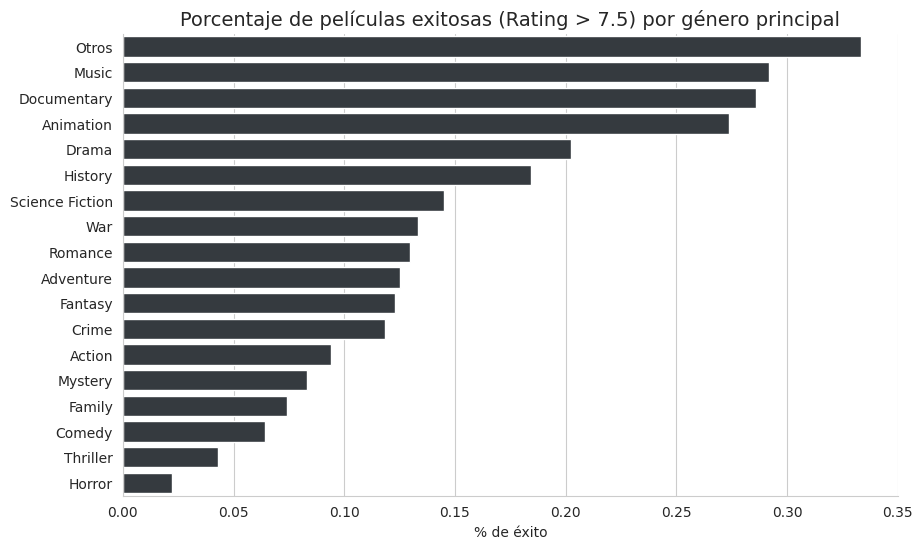

/tmp/ipykernel_1581/621795907.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exito_Rating', y='Vote_Count', palette=['#cce3de', '#a4c3b2'], ax=ax)
/tmp/ipykernel_1581/621795907.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['False', 'True'])


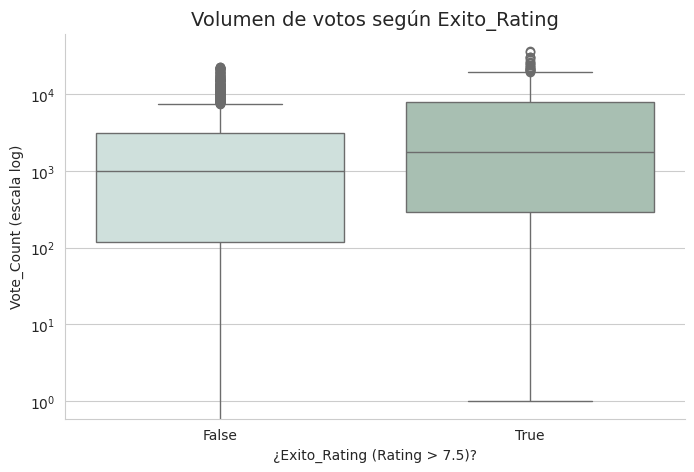

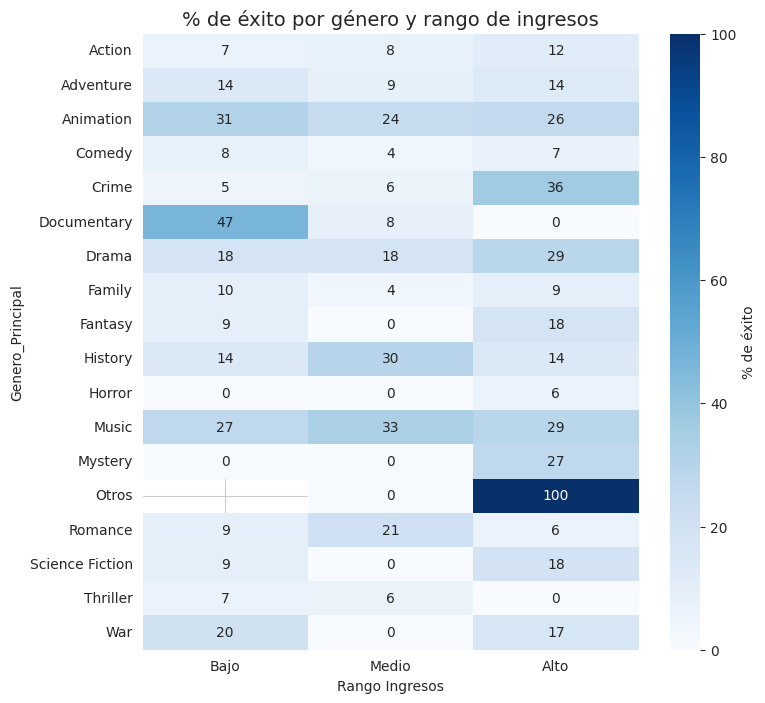

In [11]:
if not df.empty:
    # --- Gráfica 1: Tasa de éxito por género ---
    tasa_exito_genero = df.groupby('Genero_Principal')['Exito_Rating'].mean().sort_values(ascending=False).reset_index()
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=tasa_exito_genero, x='Exito_Rating', y='Genero_Principal', color='#343a40', ax=ax)
    ax.set_title('Porcentaje de películas exitosas (Rating > 7.5) por género principal', fontsize=14)
    ax.set_xlabel('% de éxito')
    ax.set_ylabel('')
    plt.show()

    # --- Gráfica 2: Boxplot de Volumen de Votos según Éxito (Escala Logarítmica) ---
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df, x='Exito_Rating', y='Vote_Count', palette=['#cce3de', '#a4c3b2'], ax=ax)
    ax.set_yscale('log')
    ax.set_title('Volumen de votos según Exito_Rating', fontsize=14)
    ax.set_xlabel('¿Exito_Rating (Rating > 7.5)?')
    ax.set_ylabel('Vote_Count (escala log)')
    ax.set_xticklabels(['False', 'True'])
    plt.show()

    # --- Gráfica 3: Heatmap de % de éxito por género y rango de ingresos ---
    heatmap_data = df.groupby(['Genero_Principal', 'Rango_Ingresos'], observed=False)['Exito_Rating'].mean().unstack() * 100
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues", cbar_kws={'label': '% de éxito'}, ax=ax)
    ax.set_title('% de éxito por género y rango de ingresos', fontsize=14)
    ax.set_xlabel('Rango Ingresos')
    ax.set_ylabel('Genero_Principal')
    plt.show()

## 4. Modelado Estadístico y de Machine Learning
Para pasar de la exploración a la predicción, preparamos nuestros datos. Convertimos los géneros en variables numéricas (Dummies) y escalamos los valores (como los ingresos y votos) para evitar que variables con números más grandes dominen el modelo de Regresión.

In [12]:
if not df.empty:
    # 1. Convertimos nuestra variable categórica de género en múltiples columnas de 1s y 0s
    df_ml = pd.get_dummies(df[['Vote_Count', '$Worldwide', 'Genero_Principal', 'Exito_Rating']], columns=['Genero_Principal'], drop_first=True)

    X = df_ml.drop(columns=['Exito_Rating'])
    y = df_ml['Exito_Rating']
    FEATURE_NAMES = X.columns.tolist()

    # 2. Partición Estratificada: Separamos un 20% de los datos para prueba, manteniendo la proporción original de películas exitosas.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 3. Estandarización: Ajustamos la escala basándonos SOLO en el conjunto de entrenamiento.
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    print("Dimensiones de nuestros datos de entrenamiento:", X_train_sc.shape)
    print("Dimensiones de nuestros datos de prueba:", X_test_sc.shape)

Dimensiones de nuestros datos de entrenamiento: (2291, 19)
Dimensiones de nuestros datos de prueba: (573, 19)


### Modelo 1: Regresión Logística
Entrenamos nuestro primer modelo de clasificación. Decidimos usar una Regresión Logística porque nos permite una alta interpretabilidad de cómo cada variable suma o resta probabilidad a que la película sea exitosa.

--- Resultados de nuestra Regresión Logística ---
Accuracy: 0.885
ROC-AUC:  0.725


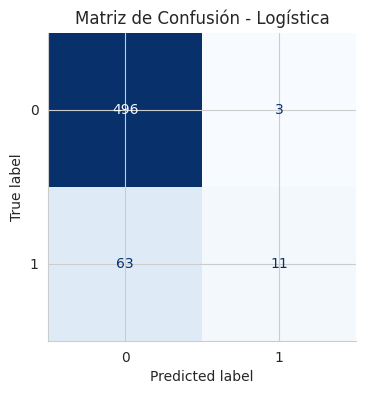

In [13]:
if not df.empty:
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(X_train_sc, y_train)

    y_pred_log = log_reg.predict(X_test_sc)
    y_proba_log = log_reg.predict_proba(X_test_sc)[:, 1]

    print("--- Resultados de nuestra Regresión Logística ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.3f}")
    print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_log):.3f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title("Matriz de Confusión - Logística")
    plt.show()

### Modelo 2: Random Forest
Para capturar patrones más complejos que no necesariamente son lineales, entrenamos un bosque aleatorio (Random Forest). Este modelo de ensamble nos ayuda a reducir el riesgo de sobreajuste y nos revela de manera muy clara cuáles son las variables más importantes.

--- Resultados de nuestro Random Forest ---
Accuracy en test: 0.881
ROC-AUC:          0.699



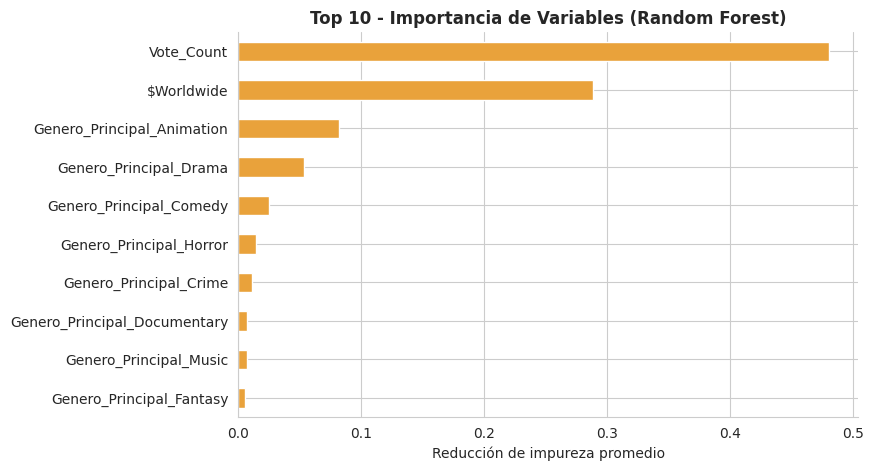

In [14]:
if not df.empty:
    # Random Forest no necesita que escalemos los datos, así que usamos X_train y X_test originales
    rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, oob_score=True)
    rf.fit(X_train, y_train)

    y_pred_rf = rf.predict(X_test)
    y_proba_rf = rf.predict_proba(X_test)[:, 1]

    print("--- Resultados de nuestro Random Forest ---")
    print(f"Accuracy en test: {accuracy_score(y_test, y_pred_rf):.3f}")
    print(f"ROC-AUC:          {roc_auc_score(y_test, y_proba_rf):.3f}\n")

    # Extraemos la importancia de las variables según el modelo
    importancia_rf = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True).tail(10)

    fig, ax = plt.subplots(figsize=(8, 5))
    importancia_rf.plot(kind="barh", color="#E9A23B", ax=ax)
    ax.set_title("Top 10 - Importancia de Variables (Random Forest)", fontweight='bold')
    ax.set_xlabel("Reducción de impureza promedio")
    plt.show()

## 5. Conclusiones y Aprendizajes
1. **La limpieza de datos fue fundamental:** Como vimos en nuestra comparación "Crudo vs Limpio", no podíamos confiar en métricas con registros nulos o formatos inconsistentes. Nuestro modelo requería datos 100% íntegros.
2. **El poder de los Votos:** Confirmamos mediante el análisis exploratorio y la importancia de variables del Random Forest que el volumen de interacción (`Vote_Count`) está profundamente ligado al éxito de la cinta.
3. **Ingresos y Géneros:** El mapa de calor nos demostró que la relación no es directa. Los documentales y musicales logran altísimos índices de éxito crítico sin necesidad de llegar al rango "Alto" de ingresos, mientras que géneros como el Misterio dependen más de un rango "Alto" de recaudación para ser percibidos como éxitos absolutos.
